In [1]:
# Install the module when it is not available (e.g. on Colab). Locally: `pip install -e .` from the repository root.
try:
    import mvg
except ImportError:
    %pip install -q git+https://github.com/Rudip1/learn-computer-vision
    import mvg

# 2 · The pinhole camera

**Recap** ([theory](../../1_theory/02_pinhole_camera.md)).

* World → camera: $\tilde{\mathbf{X}}_c = R\tilde{\mathbf{X}}_w + \mathbf{t}$; the camera centre is $\tilde{\mathbf{C}} = -R^\top\mathbf{t}$.
* Central projection: $(x_n, y_n) = (X_c/Z_c, Y_c/Z_c)$; pixels: $(u, v, 1)^\top = K(x_n, y_n, 1)^\top$.
* Together: $\mathbf{x} \simeq P\mathbf{X}$ with $P = K[R \mid \mathbf{t}]$, 11 degrees of freedom.
* Lens distortion acts on normalized coordinates; its inverse needs an iterative solver (Newton).
* A pixel back-projects to a ray $\tilde{\mathbf{C}} + \lambda R^\top K^{-1}\mathbf{x}$; depth fixes the point.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mvg
from mvg.datasets import cube, random_points
from mvg.plotting import setup, draw_camera, set_axes_equal, image_axes

setup()
rng = np.random.default_rng(1)
np.set_printoptions(precision=4, suppress=True)

## 1. Rotations

An Euler sequence is a product of elementary rotations in the stated order. Repeated-axis sequences such as XYX
are valid too.

In [3]:
R = mvg.rotation_from_euler("XYX", [0.4 * np.pi, -0.9 * np.pi, np.pi / 5])
print("R =\n", R)
print("is a rotation:", mvg.is_rotation(R), "  det =", np.linalg.det(R))
w = mvg.so3_log(R)
print("rotation vector:", w, " angle =", np.degrees(np.linalg.norm(w)), "deg")
print("exp(log(R)) == R:", np.allclose(mvg.so3_exp(w), R))

R =
 [[-0.9511 -0.1816 -0.25  ]
 [-0.2939  0.7817  0.5501]
 [ 0.0955  0.5967 -0.7968]]
is a rotation: True   det = 0.9999999999999999
rotation vector: [ 0.3759 -2.7899 -0.9065]  angle = 169.44841654811216 deg
exp(log(R)) == R: True


### ✏️ Exercise 2.1 — Rodrigues' formula

Implement eq. (2.2), including a branch for very small angles (where $\sin\theta/\theta$ is evaluated as 0/0).

In [4]:
def rodrigues(w):
    w = np.asarray(w, dtype=float)
    th2 = w @ w
    th = np.sqrt(th2)
    if th < 1e-4:
        a, b = 1 - th2 / 6, 0.5 - th2 / 24
    else:
        a, b = np.sin(th) / th, (1 - np.cos(th)) / th2
    W = mvg.skew(w)
    return np.eye(3) + a * W + b * W @ W

In [5]:
for scale in [0.0, 1e-9, 1e-3, 1.0, 3.0]:
    for _ in range(20):
        w = rng.normal(size=3)
        w *= scale / max(np.linalg.norm(w), 1e-300)
        assert np.allclose(rodrigues(w), mvg.so3_exp(w), atol=1e-12)
print("Exercise 2.1 passed")

Exercise 2.1 passed


## 2. Placing a camera and projecting a scene

A cube on the floor and a cloud of random points, seen by a camera placed with *look-at* (eq. 2.7).

P =
 [[  99.6497  593.8469 -101.0733 1367.6001]
 [ -48.7588   40.6323 -569.185  1272.3901]
 [  -0.7289    0.6074   -0.3159    4.2738]]
camera centre: [ 3.  -2.5  1.8]  horizontal FOV: 63.2 deg


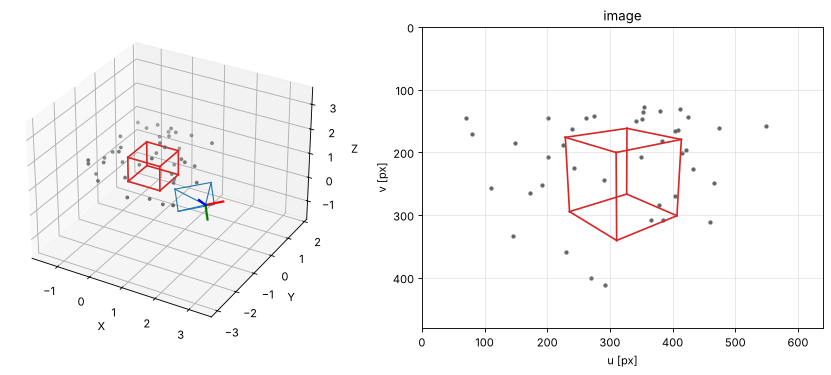

In [6]:
corners, edges = cube(1.0, origin=(-0.5, -0.5, 0.0))
cloud = random_points(40, [-1.5, -1.5, 0.0], [1.5, 1.5, 1.5], rng=2)

K = mvg.make_intrinsics(520.0, 520.0, 320.0, 240.0)
C = np.array([3.0, -2.5, 1.8])
R = mvg.look_at(C, [0.0, 0.0, 0.5], [0.0, 0.0, 1.0])
cam = mvg.PinholeCamera(K, 640, 480, R, -R @ C)
print("P =\n", cam.P())
print("camera centre:", cam.center(), " horizontal FOV: %.1f deg" % np.degrees(mvg.field_of_view(640, 520)))


def draw_scene(ax3d, cams=()):
    for a, b in edges:
        ax3d.plot(*corners[[a, b]].T, color="C1")
    ax3d.scatter(*cloud.T, s=6, color="0.4")
    for c in cams:
        draw_camera(ax3d, c, depth=0.8)
    ax3d.set_xlabel("X"); ax3d.set_ylabel("Y"); ax3d.set_zlabel("Z")
    set_axes_equal(ax3d)


def draw_image(ax, c, title=None):
    px = c.project(corners)
    for a, b in edges:
        ax.plot(*px[[a, b]].T, color="C1")
    vis = c.is_visible(cloud)
    ax.scatter(*c.project(cloud[vis]).T, s=8, color="0.4")
    image_axes(ax, c.width, c.height, title)


fig = plt.figure(figsize=(11, 4.5))
draw_scene(fig.add_subplot(1, 2, 1, projection="3d"), [cam])
draw_image(fig.add_subplot(1, 2, 2), cam, "image")
plt.tight_layout()

### ✏️ Exercise 2.2 — the camera centre from $P$ alone

$P\mathbf{C} = \mathbf{0}$: the centre is the right null vector of $P$. Find it with an SVD and dehomogenize it.

In [7]:
def centre_from_P(P):
    _, _, Vt = np.linalg.svd(P)
    c = Vt[-1]
    return c[:3] / c[3]

In [8]:
assert np.allclose(centre_from_P(cam.P()), C)
assert np.allclose(centre_from_P(5.0 * cam.P()), C)  # the scale of P does not matter
print("Exercise 2.2 passed")

Exercise 2.2 passed


The left $3\times 3$ block $M = KR$ maps world directions to vanishing points. The three world axes:

In [9]:
M = cam.P()[:, :3]
for name, d in zip("XYZ", np.eye(3)):
    v = M @ d
    print(f"vanishing point of the world {name} axis: {v[:2] / v[2]}")

vanishing point of the world X axis: [-136.7135   66.8941]
vanishing point of the world Y axis: [977.6675  66.8941]
vanishing point of the world Z axis: [ 320.     1802.0499]


## 3. Zoom versus move

Keep the front face of the cube the same size in the image while moving the camera away and increasing the focal
length. Distant cameras with long lenses flatten the perspective: the back face grows towards the size of the front.

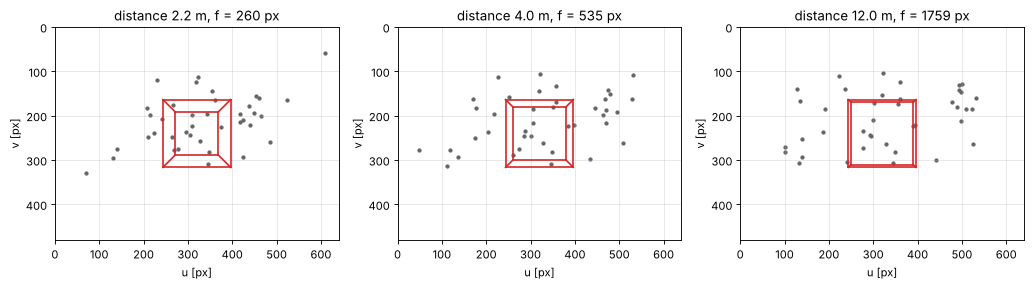

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, dist in zip(axes, [2.2, 4.0, 12.0]):
    f = 260.0 * (dist - 0.5) / 1.7  # front face at x = 0.5: keep f / (distance to it) constant
    c_pos = np.array([dist, 0.0, 0.5])
    Rd = mvg.look_at(c_pos, [0.0, 0.0, 0.5], [0, 0, 1])
    c = mvg.PinholeCamera(mvg.make_intrinsics(f, f, 320, 240), 640, 480, Rd, -Rd @ c_pos)
    draw_image(ax, c, f"distance {dist} m, f = {f:.0f} px")
plt.tight_layout()

## 4. Lens distortion

The same grid of normalized points with barrel ($k_1 < 0$) and pincushion ($k_1 > 0$) distortion.

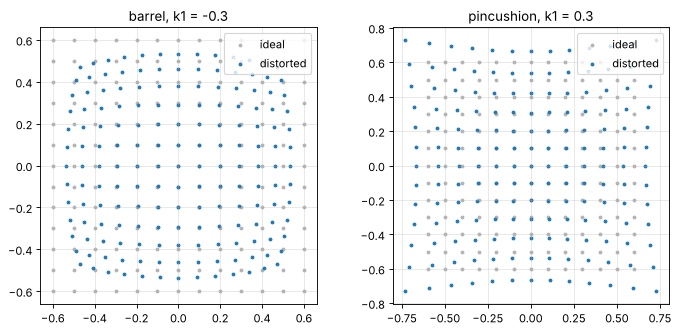

In [11]:
g = np.linspace(-0.6, 0.6, 13)
grid = np.array([[x, y] for x in g for y in g])
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, k1 in zip(axes, [-0.3, 0.3]):
    d = mvg.Distortion(k1=k1)
    ax.scatter(*grid.T, s=6, color="0.7", label="ideal")
    ax.scatter(*mvg.distort(grid, d).T, s=6, label="distorted")
    ax.set_title(("barrel" if k1 < 0 else "pincushion") + f", k1 = {k1}")
    ax.set_aspect("equal"); ax.legend(loc="upper right")
plt.tight_layout()

**Reference check.** OpenCV implements the same model. If it is installed, compare the full projection on the
cloud of points.

In [12]:
dist = mvg.Distortion(k1=-0.21, k2=0.05, p1=8e-4, p2=-5e-4, k3=-0.004)
cam_d = mvg.PinholeCamera(K, 640, 480, cam.R, cam.t, dist)
try:
    import cv2
    ref, _ = cv2.projectPoints(cloud, cv2.Rodrigues(cam.R)[0], cam.t, K, dist.as_vector())
    print("max |mvg - OpenCV| =", np.abs(ref[:, 0, :] - cam_d.project(cloud)).max(), "px")
except ImportError:
    print("OpenCV not installed; skipping the reference comparison")

max |mvg - OpenCV| = 1.1368683772161603e-13 px


### ✏️ Exercise 2.3 — the distortion model

Implement eq. (2.12) for an $N \times 2$ array of normalized points.

In [13]:
def distort(xn, k1, k2, p1, p2, k3):
    x, y = xn[:, 0], xn[:, 1]
    r2 = x * x + y * y
    radial = 1 + k1 * r2 + k2 * r2**2 + k3 * r2**3
    xd = x * radial + 2 * p1 * x * y + p2 * (r2 + 2 * x * x)
    yd = y * radial + p1 * (r2 + 2 * y * y) + 2 * p2 * x * y
    return np.column_stack([xd, yd])

In [14]:
xn = rng.uniform(-0.6, 0.6, size=(100, 2))
assert np.allclose(distort(xn, *dist.as_vector()), mvg.distort(xn, dist), atol=1e-14)
print("Exercise 2.3 passed")

Exercise 2.3 passed


Undistortion runs Newton's method (2.13). The round trip is exact to machine precision inside the image:

In [15]:
px = cam_d.project(cloud[cam_d.is_visible(cloud)])
xd = mvg.pixels_to_normalized(K, px)
xn = mvg.undistort(xd, dist)
print("max round-trip error:", np.abs(mvg.distort(xn, dist) - xd).max())

max round-trip error: 7.382983113757291e-15


## 5. Back-projection

Pixels plus depth give back the points (section 2.5); pixels alone give rays through the camera centre.

max reconstruction error: 2.350897254643769e-14 m


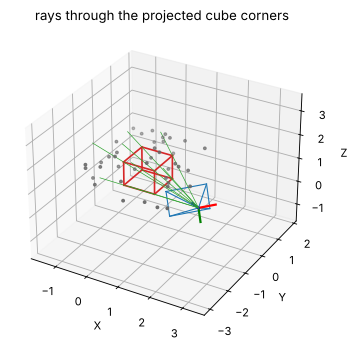

In [16]:
Xc = cam_d.to_camera(corners)
px = cam_d.project(corners)
back = cam_d.backproject(px, Xc[:, 2])
print("max reconstruction error:", np.abs(back - corners).max(), "m")

rays = cam_d.rays(px)
fig = plt.figure(figsize=(5.5, 5))
ax = fig.add_subplot(projection="3d")
draw_scene(ax, [cam_d])
for r in rays:
    ax.plot(*np.vstack([cam_d.center(), cam_d.center() + 6 * r]).T, color="C2", lw=0.6)
set_axes_equal(ax); ax.set_title("rays through the projected cube corners");

## 🔨 Break it

**Points behind the camera.** The pinhole equations do not know about "behind": a point at $-\mathbf{X}_c$ lands
on the same pixel as $\mathbf{X}_c$.

In [17]:
Xc_front = np.array([[0.3, -0.2, 2.0]])
Xw_front = (cam.R.T @ (Xc_front[0] - cam.t))[None]
Xw_behind = (cam.R.T @ (-Xc_front[0] - cam.t))[None]
print("front :", cam.project(Xw_front), "visible:", cam.is_visible(Xw_front))
print("behind:", cam.project(Xw_behind), "visible:", cam.is_visible(Xw_behind))

front : [[398. 188.]] visible: [ True]
behind: [[398. 188.]] visible: [False]


**Undistortion beyond the fold.** With strong barrel distortion the radial map $r \mapsto r(1 + k_1 r^2)$ turns
back at $r = 1/\sqrt{-3k_1}$. Beyond it two points have the same distorted radius, and Newton cannot tell which
one was meant.

fold at r = 0.913; error beyond the fold: 1.349


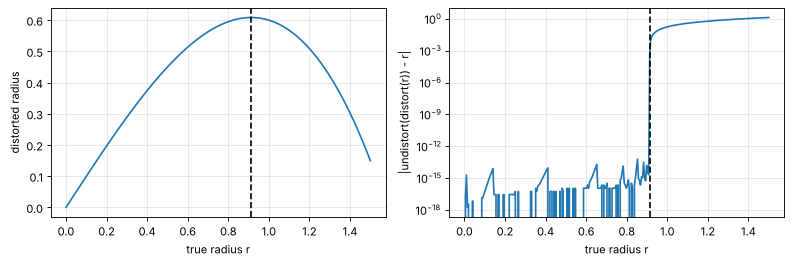

In [18]:
k1 = -0.4
r = np.linspace(0, 1.5, 300)
r_fold = 1 / np.sqrt(-3 * k1)
d = mvg.Distortion(k1=k1)
pts = np.column_stack([r, np.zeros_like(r)])
back = mvg.undistort(mvg.distort(pts, d), d)[:, 0]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(r, r * (1 + k1 * r**2)); axes[0].axvline(r_fold, color="k", ls="--")
axes[0].set_xlabel("true radius r"); axes[0].set_ylabel("distorted radius")
axes[1].plot(r, np.abs(back - r)); axes[1].axvline(r_fold, color="k", ls="--"); axes[1].set_yscale("log")
axes[1].set_xlabel("true radius r"); axes[1].set_ylabel("|undistort(distort(r)) - r|")
plt.tight_layout()
print(f"fold at r = {r_fold:.3f}; error beyond the fold: {np.abs(back - r)[r > r_fold + 0.05].max():.3f}")

**Pose instead of extrinsics.** Pass the camera *pose* rotation $R_{wc} = R^\top$ where the extrinsic rotation
$R_{cw}$ is expected. Nothing fails loudly — the result is simply a different, plausible-looking image.

visible points: 40 (right) vs 38 (wrong); median pixel displacement 162 px


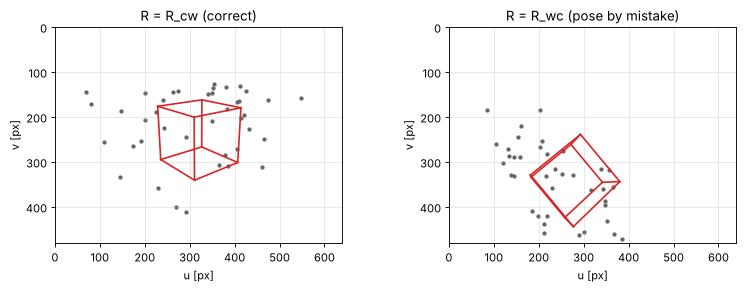

In [19]:
wrong = mvg.PinholeCamera(K, 640, 480, cam.R.T, -cam.R @ C)
shift = np.linalg.norm(wrong.project(cloud) - cam.project(cloud), axis=1)
print(f"visible points: {cam.is_visible(cloud).sum()} (right) vs {wrong.is_visible(cloud).sum()} (wrong); "
      f"median pixel displacement {np.median(shift):.0f} px")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
draw_image(axes[0], cam, "R = R_cw (correct)")
draw_image(axes[1], wrong, "R = R_wc (pose by mistake)")
plt.tight_layout()

## What to remember

* $P = K[R \mid \mathbf{t}]$ with $R, \mathbf{t}$ mapping **world to camera**; the camera pose is the inverse.
* The camera centre is the null vector of $P$; $KR$ maps directions to vanishing points.
* Distortion lives in normalized coordinates; undistortion is an iterative inverse that only works up to the fold.
* A pixel is a ray; depth (or a known plane) is needed to get a point.
* Always check cheirality ($Z_c > 0$) before trusting a projection.